In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the cleaned dataset from Phase 1
df = pd.read_parquet(PROCESSED_DIR / 'cyclists_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 37,488,307 rows × 27 columns


In [8]:
# Use 2022–2025 for clustering (exclude COVID years)
# Full 2020–2025 will be used in Phase 3 with is_covid flag
df_cluster = df[df['year'] >= 2022].copy()
print(f'Years used for clustering: {sorted(df_cluster["year"].unique())}')
print(f'Rows after COVID filter: {df_cluster.shape[0]:,}')

# Aggregate mean counts per site, day of week, hour (sums IN + OUT automatically)
hourly = (
    df_cluster
    .groupby(['site_id', 'day_of_week', 'hour'])['aantal']
    .mean()
    .reset_index()
)
print(f'Hourly aggregation shape: {hourly.shape}')
hourly.head()

Years used for clustering: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Rows after COVID filter: 33,965,135
Hourly aggregation shape: (23688, 4)


,site_id,day_of_week,hour,aantal
0,1,0,0,0.220096
1,1,0,1,0.088517
2,1,0,2,0.159689
3,1,0,3,0.116627
4,1,0,4,0.274522


In [9]:
# Pivot: one row per site, 168 columns (7 days × 24 hours)
profiles = hourly.pivot_table(
    index='site_id',
    columns=['day_of_week', 'hour'],
    values='aantal',
    aggfunc='mean'
)

# Flatten column names → "day0_h0", "day0_h1" … "day6_h23"
profiles.columns = [f'day{d}_h{h}' for d, h in profiles.columns]

# Fill any missing slots with 0
profiles = profiles.fillna(0)

print(f'Profile matrix shape: {profiles.shape}')
print(f'Expected: ({df_cluster["site_id"].nunique()} sites × 168 features)')
profiles.head(3)

Profile matrix shape: (141, 168)
Expected: (141 sites × 168 features)


,day0_h0,day0_h1,day0_h2,day0_h3,day0_h4,day0_h5,day0_h6,day0_h7,day0_h8,day0_h9,...,day6_h14,day6_h15,day6_h16,day6_h17,day6_h18,day6_h19,day6_h20,day6_h21,day6_h22,day6_h23
site_id,,,,,,,,,,,,,,,,,,,,,
1,0.220096,0.088517,0.159689,0.116627,0.274522,0.848086,3.175239,5.438995,5.223684,2.046651,...,2.922847,2.826555,2.299641,2.156100,1.553230,1.392943,1.870813,0.756579,0.468900,0.253589
2,0.281699,0.163876,0.144737,0.184211,0.550837,2.330144,5.279306,14.468900,17.890550,5.070574,...,4.760167,3.985048,4.063397,3.763158,2.588517,2.127392,1.898923,1.553230,1.293062,0.521531
3,0.538876,0.233852,0.116627,0.166866,0.251196,1.334928,2.393541,10.642344,9.099282,3.754785,...,4.442584,4.122010,3.900120,3.115431,2.636962,1.977273,1.662679,1.551435,1.188397,0.729067


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(profiles)

print(f'Scaled matrix shape: {profiles_scaled.shape}')
print(f'Mean ≈ {profiles_scaled.mean():.4f}  (should be ~0)')
print(f'Std  ≈ {profiles_scaled.std():.4f}   (should be ~1)')

Scaled matrix shape: (141, 168)
Mean ≈ 0.0000  (should be ~0)
Std  ≈ 1.0000   (should be ~1)


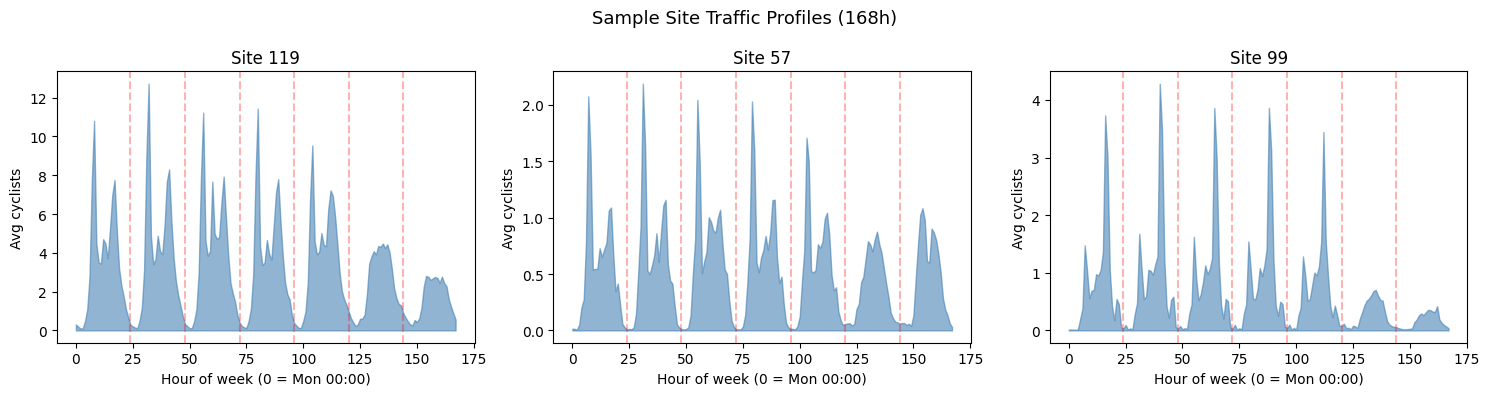

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sample_sites = profiles.sample(3, random_state=22).index

for ax, site_id in zip(axes, sample_sites):
    profile = profiles.loc[site_id].values
    ax.fill_between(range(168), profile, alpha=0.6, color='steelblue')
    ax.set_title(f'Site {site_id}')
    ax.set_xlabel('Hour of week (0 = Mon 00:00)')
    ax.set_ylabel('Avg cyclists')
    for day in range(1, 7):
        ax.axvline(day * 24, color='red', linestyle='--', alpha=0.3)

plt.suptitle('Sample Site Traffic Profiles (168h)', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
print(f'Profile matrix shape: {profiles.shape}')
print(f'Any NaN values: {profiles.isna().sum().sum()}')
print(f'Any all-zero sites: {(profiles.sum(axis=1) == 0).sum()}')

Profile matrix shape: (141, 168)
Any NaN values: 0
Any all-zero sites: 0


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(profiles_scaled, labels))
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={silhouette_score(profiles_scaled, labels):.3f}')

k=2  inertia=10866.6  silhouette=0.755
k=3  inertia=7069.4  silhouette=0.699
k=4  inertia=5316.5  silhouette=0.450
k=5  inertia=4661.2  silhouette=0.448
k=6  inertia=4212.0  silhouette=0.243
k=7  inertia=3738.3  silhouette=0.397
k=8  inertia=3222.8  silhouette=0.245
k=9  inertia=3051.4  silhouette=0.250


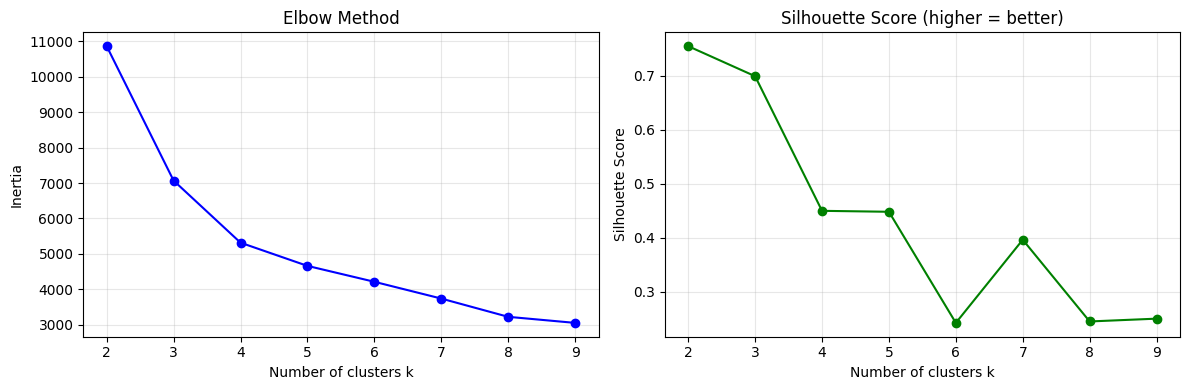

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K, inertias, 'bo-')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(K, silhouettes, 'go-')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.cluster import KMeans

k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
profiles['cluster'] = km.fit_predict(profiles_scaled)

print(profiles['cluster'].value_counts().sort_index())

cluster
0    129
1     10
2      2
Name: count, dtype: int64


In [22]:
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_scaled)
    print(f'k={k}: {dict(zip(*np.unique(labels, return_counts=True)))}')

k=3: {np.int32(0): np.int64(129), np.int32(1): np.int64(10), np.int32(2): np.int64(2)}
k=4: {np.int32(0): np.int64(97), np.int32(1): np.int64(8), np.int32(2): np.int64(34), np.int32(3): np.int64(2)}
k=5: {np.int32(0): np.int64(33), np.int32(1): np.int64(2), np.int32(2): np.int64(97), np.int32(3): np.int64(8), np.int32(4): np.int64(1)}


In [23]:
profiles_norm = profiles.drop(columns='cluster').div(
    profiles.drop(columns='cluster').max(axis=1), axis=0
)
profiles_norm = profiles_norm.fillna(0)

scaler_s = StandardScaler()
profiles_scaled_s = scaler_s.fit_transform(profiles_norm)

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_scaled_s)
    print(f'k={k}: {dict(zip(*np.unique(labels, return_counts=True)))}')

k=3: {np.int32(0): np.int64(42), np.int32(1): np.int64(72), np.int32(2): np.int64(27)}
k=4: {np.int32(0): np.int64(54), np.int32(1): np.int64(64), np.int32(2): np.int64(22), np.int32(3): np.int64(1)}
k=5: {np.int32(0): np.int64(41), np.int32(1): np.int64(35), np.int32(2): np.int64(62), np.int32(3): np.int64(2), np.int32(4): np.int64(1)}


In [24]:
from sklearn.preprocessing import RobustScaler

scaler_r = RobustScaler()
profiles_scaled_r = scaler_r.fit_transform(profiles.drop(columns='cluster'))

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_scaled_r)
    print(f'k={k}: {dict(zip(*np.unique(labels, return_counts=True)))}')

k=3: {np.int32(0): np.int64(129), np.int32(1): np.int64(10), np.int32(2): np.int64(2)}
k=4: {np.int32(0): np.int64(99), np.int32(1): np.int64(9), np.int32(2): np.int64(2), np.int32(3): np.int64(31)}
k=5: {np.int32(0): np.int64(103), np.int32(1): np.int64(6), np.int32(2): np.int64(29), np.int32(3): np.int64(2), np.int32(4): np.int64(1)}


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)
profiles_pca = pca.fit_transform(profiles_scaled_r)
print(f'Variance explained by 20 components: {pca.explained_variance_ratio_.sum():.1%}')

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_pca)
    print(f'k={k}: {dict(zip(*np.unique(labels, return_counts=True)))}')

Variance explained by 20 components: 99.4%
k=3: {np.int32(0): np.int64(129), np.int32(1): np.int64(10), np.int32(2): np.int64(2)}
k=4: {np.int32(0): np.int64(31), np.int32(1): np.int64(2), np.int32(2): np.int64(99), np.int32(3): np.int64(9)}
k=5: {np.int32(0): np.int64(101), np.int32(1): np.int64(7), np.int32(2): np.int64(30), np.int32(3): np.int64(2), np.int32(4): np.int64(1)}


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Fresh start from raw profiles
profiles_base = profiles.drop(columns='cluster', errors='ignore').copy()

# Option 2: peak normalisation
profiles_norm = profiles_base.div(profiles_base.max(axis=1), axis=0).fillna(0)

# Z-score scaling
scaler = StandardScaler()
profiles_scaled_final = scaler.fit_transform(profiles_norm)

print("Done — profiles_scaled_final is ready, shape:", profiles_scaled_final.shape)

Done — profiles_scaled_final is ready, shape: (141, 168)


In [28]:
pca = PCA(n_components=20, random_state=42)
profiles_pca = pca.fit_transform(profiles_scaled_final)  # ← Option 2 data, not _r
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.1%}')

for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_pca)
    print(f'k={k}: {dict(zip(*np.unique(labels, return_counts=True)))}')

Variance explained: 94.0%
k=3: {np.int32(0): np.int64(41), np.int32(1): np.int64(75), np.int32(2): np.int64(25)}
k=4: {np.int32(0): np.int64(26), np.int32(1): np.int64(41), np.int32(2): np.int64(58), np.int32(3): np.int64(16)}
k=5: {np.int32(0): np.int64(41), np.int32(1): np.int64(35), np.int32(2): np.int64(62), np.int32(3): np.int64(2), np.int32(4): np.int64(1)}


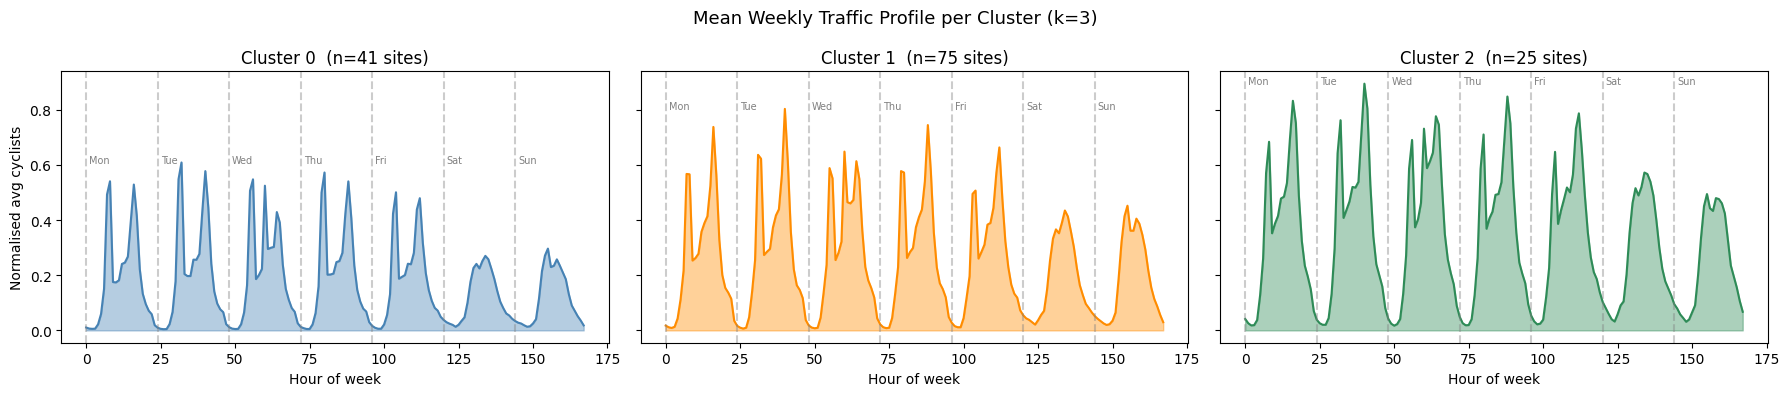

In [29]:
import matplotlib.pyplot as plt

# Get final k=3 labels from PCA clustering
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(profiles_pca)

# Attach labels to original (peak-normalised) profiles for plotting
profiles_plot = profiles_norm.copy()
profiles_plot['cluster'] = labels

# Day separators
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for c in range(3):
    ax = axes[c]
    mask = profiles_plot['cluster'] == c
    mean_profile = profiles_plot[mask].drop(columns='cluster').mean().values
    n = mask.sum()

    ax.fill_between(range(168), mean_profile, alpha=0.4, color=colors[c])
    ax.plot(mean_profile, color=colors[c], linewidth=1.5)

    for d in range(7):
        ax.axvline(d * 24, color='gray', linestyle='--', alpha=0.4)
        ax.text(d * 24 + 1, ax.get_ylim()[1] * 0.95, day_labels[d], fontsize=7, color='gray')

    ax.set_title(f'Cluster {c}  (n={n} sites)', fontsize=12)
    ax.set_xlabel('Hour of week')
    if c == 0:
        ax.set_ylabel('Normalised avg cyclists')

plt.suptitle('Mean Weekly Traffic Profile per Cluster (k=3)', fontsize=13)
plt.tight_layout()
plt.savefig('clusters_k3.png', dpi=150)
plt.show()

In [32]:
%whos DataFrame

print(df.columns.tolist())

Variable        Type         Data/Info
--------------------------------------
df              DataFrame    Shape: (37488307, 27)
df_cluster      DataFrame    Shape: (33965135, 27)
hourly          DataFrame    Shape: (23688, 4)
profiles        DataFrame    Shape: (141, 169)
profiles_base   DataFrame    Shape: (141, 168)
profiles_norm   DataFrame    Shape: (141, 168)
profiles_plot   DataFrame    Shape: (141, 169)
['site_id', 'richting', 'type', 'van', 'tot', 'aantal', 'site_nr', 'long', 'lat', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'naam_dir', 'hour', 'day_of_week', 'day_name', 'month', 'year', 'date', 'is_weekend', 'is_holiday', 'season', 'rolling_7d_avg']


In [33]:
# Extract one coordinate per site
site_coords = df[['site_id', 'lat', 'long']].drop_duplicates(subset='site_id').reset_index(drop=True)

# profiles index = site_id — check this matches
print(site_coords.shape)
print(profiles_plot.index[:5])
print(site_coords['site_id'].head())

(141, 3)
Index([1, 2, 3, 4, 5], dtype='int64', name='site_id')
0    1
1    2
2    3
3    4
4    5
Name: site_id, dtype: int64


Raw profiles → Peak normalisation → StandardScaler → PCA (20 components) → KMeans (k=3)

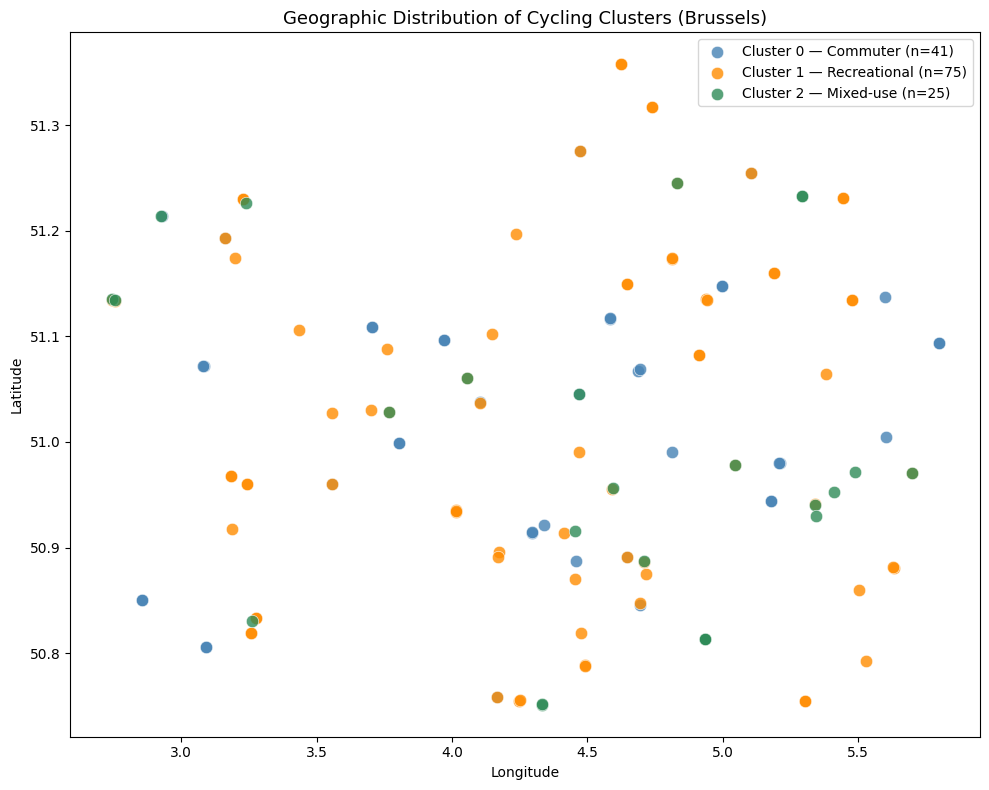

In [34]:
# Merge coordinates with cluster labels
sites_geo = site_coords.set_index('site_id')
sites_geo['cluster'] = profiles_plot['cluster']

# Plot
colors = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
cluster_names = {0: 'Commuter', 1: 'Recreational', 2: 'Mixed-use'}

fig, ax = plt.subplots(figsize=(10, 8))

for c in range(3):
    mask = sites_geo['cluster'] == c
    ax.scatter(
        sites_geo[mask]['long'],
        sites_geo[mask]['lat'],
        c=colors[c], label=f"Cluster {c} — {cluster_names[c]} (n={mask.sum()})",
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )

ax.set_title('Geographic Distribution of Cycling Clusters (Brussels)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.savefig('clusters_map.png', dpi=150)
plt.show()

In [35]:
print(df['gemeente'].value_counts().head(20))

gemeente
Brugge               1609814
Kortrijk             1474306
Tienen               1261476
Aalst                1256248
Leuven               1205228
Gent                 1045265
Nieuwpoort            988988
Westerlo              942822
Heist-op-den-Berg     841300
Balen                 840988
Oostende              840674
Brasschaat            839832
Evergem               836999
Genk                  655334
Hasselt               562772
Zaventem              542540
Lummen                522576
Herk-de-Stad          522384
Lommel                519504
Peer                  519502
Name: count, dtype: int64


install this pip install contextily

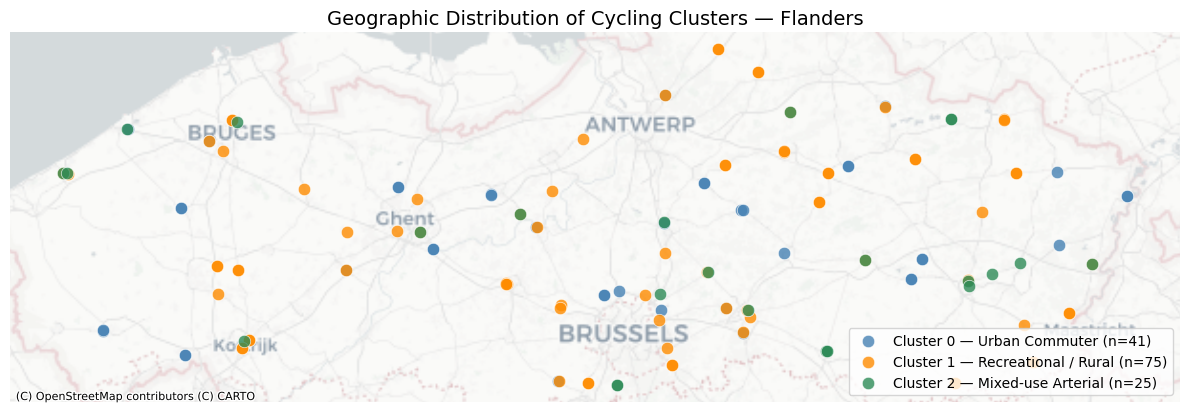

In [36]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    sites_geo,
    geometry=[Point(xy) for xy in zip(sites_geo['long'], sites_geo['lat'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)  # Web Mercator for basemap

colors = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
cluster_names = {0: 'Urban Commuter', 1: 'Recreational / Rural', 2: 'Mixed-use Arterial'}

fig, ax = plt.subplots(figsize=(12, 10))

for c in range(3):
    mask = gdf['cluster'] == c
    gdf[mask].plot(
        ax=ax,
        color=colors[c],
        markersize=80,
        alpha=0.8,
        label=f"Cluster {c} — {cluster_names[c]} (n={mask.sum()})",
        edgecolor='white',
        linewidth=0.5
    )

# Add real basemap (OpenStreetMap)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

ax.set_title('Geographic Distribution of Cycling Clusters — Flanders', fontsize=14)
ax.set_axis_off()
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('clusters_map_real.png', dpi=150)
plt.show()

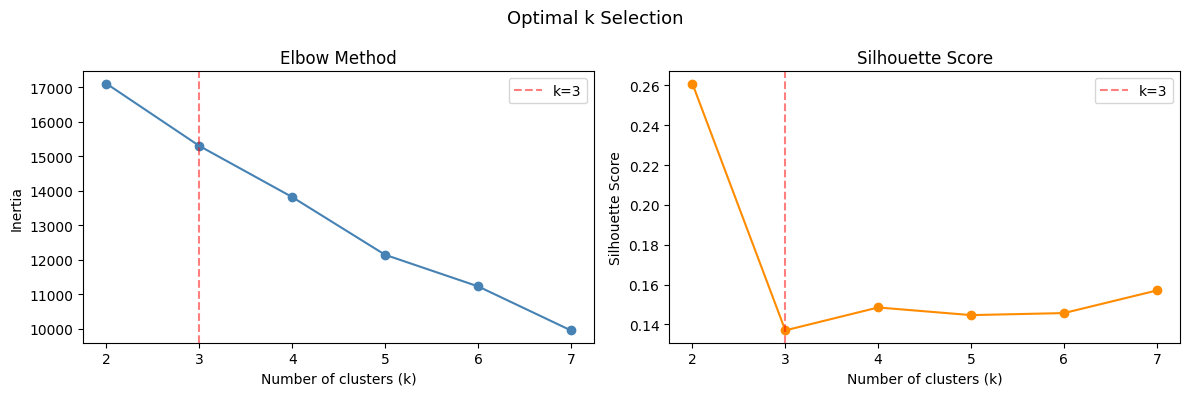

Silhouette scores: {2: 0.261, 3: 0.137, 4: 0.148, 5: 0.145, 6: 0.146, 7: 0.157}


In [37]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(profiles_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(profiles_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, 'o-', color='steelblue')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax1.legend()

ax2.plot(k_range, silhouettes, 'o-', color='darkorange')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3')
ax2.legend()

plt.suptitle('Optimal k Selection', fontsize=13)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

print(f"Silhouette scores: { {k: round(s, 3) for k, s in zip(k_range, silhouettes)} }")

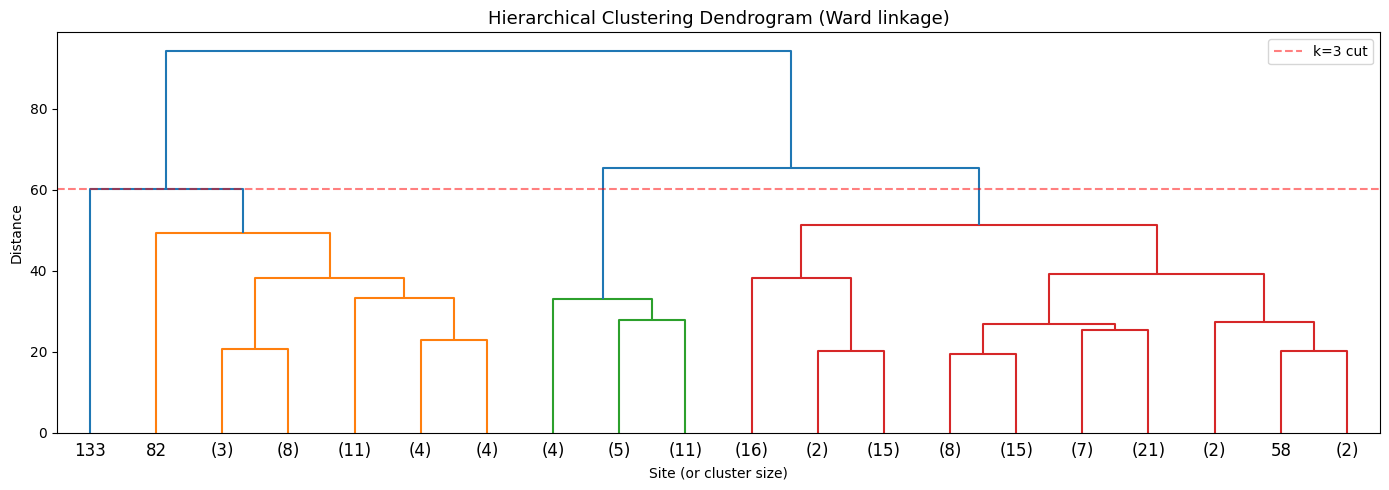

Adjusted Rand Index (KMeans vs Hierarchical): 0.230
Hierarchical k=3: {np.int32(0): np.int64(32), np.int32(1): np.int64(20), np.int32(2): np.int64(89)}


In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Build linkage matrix
Z = linkage(profiles_pca, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20, ax=ax,
           color_threshold=Z[-3, 2])
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)', fontsize=13)
ax.set_xlabel('Site (or cluster size)')
ax.set_ylabel('Distance')
ax.axhline(Z[-3, 2], color='red', linestyle='--', alpha=0.5, label='k=3 cut')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# Compare hierarchical vs KMeans labels
hier_labels = fcluster(Z, t=3, criterion='maxclust') - 1  # 0-indexed
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_final.fit_predict(profiles_pca)

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(hier_labels, km_labels)
print(f"Adjusted Rand Index (KMeans vs Hierarchical): {ari:.3f}")
print(f"Hierarchical k=3: {dict(zip(*np.unique(hier_labels, return_counts=True)))}")

In [39]:
from sklearn.mixture import GaussianMixture

bics = []
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(profiles_pca)
    bics.append(gmm.bic(profiles_pca))

# Pick k with lowest BIC
import numpy as np
best_k = range(2, 8)[np.argmin(bics)]
print(f"Best k by BIC: {best_k}")
print(f"BIC scores: {dict(zip(range(2,8), [round(b) for b in bics]))}")

Best k by BIC: 3
BIC scores: {2: 12505, 3: 11912, 4: 11995, 5: 12487, 6: 12139, 7: 12224}
